In [1]:
import cu_rsc as cr
cr.setup_tables()
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from tqdm import tqdm
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

### New sequence optimize with 10 kHz rabi cap

In [2]:
seq_op = np.load("../../new_sequence_optimization/op_amp_time/omega_time_ga_runs/OmegaTimeGA_20260210_141340/final_top5/top1_sequence.npy")

In [3]:
print(np.unique(seq_op, axis=0))

[[ 0.00000000e+00 -3.00000000e+00  1.84187616e+04  7.63928164e-05]
 [ 0.00000000e+00 -2.00000000e+00  1.45368382e+04  9.39173207e-05]
 [ 0.00000000e+00 -1.00000000e+00  7.84287242e+03  1.34476841e-04]
 [ 1.00000000e+00 -3.00000000e+00  1.85722610e+04  7.00206985e-05]
 [ 1.00000000e+00 -2.00000000e+00  1.18053453e+04  1.04600718e-04]
 [ 1.00000000e+00 -1.00000000e+00  5.65819742e+03  1.58817067e-04]
 [ 2.00000000e+00 -1.00000000e+01  1.40685998e+04  2.66231928e-05]
 [ 2.00000000e+00 -9.00000000e+00  1.86541078e+04  4.27740350e-05]
 [ 2.00000000e+00 -8.00000000e+00  2.03898282e+04  4.10213287e-05]
 [ 2.00000000e+00 -7.00000000e+00  1.16945943e+04  2.18312536e-05]
 [ 2.00000000e+00 -6.00000000e+00  1.05042107e+04  4.91887879e-05]
 [ 2.00000000e+00 -5.00000000e+00  1.47106574e+04  1.46294961e-04]
 [ 2.00000000e+00 -4.00000000e+00  5.03915688e+03  1.15801219e-04]
 [ 2.00000000e+00 -3.00000000e+00  2.26278639e+03  1.86457720e-04]
 [ 2.00000000e+00 -2.00000000e+00  3.99946633e+03  2.20509975e

In [5]:
seq_list = np.unique(seq_op, axis=0)
np.save("seq_list_nocap_0406.npy", seq_list)

In [4]:
np.save("seq_nocap_0406.npy", seq_op)

In [11]:
cap_rabi = 1e4
seq_cap = seq_op
for i, seq in enumerate(seq_cap):
    if seq[0]==2 and seq[2]>cap_rabi:
        seq_cap[i, 2] = cap_rabi

### no cap

Raman pulses: 100%|██████████| 260/260 [00:16<00:00, 15.40it/s]


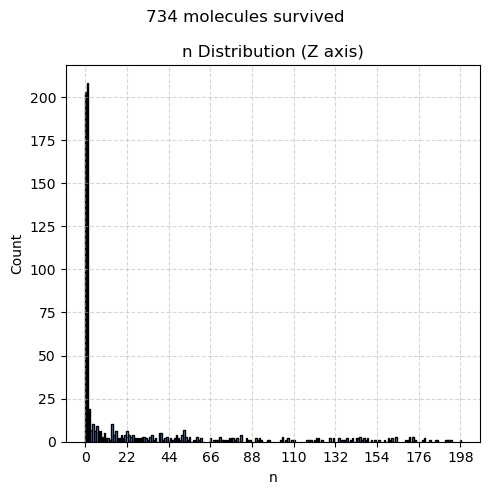

{'survival_rate_mean': array(0.734),
 'survival_rate_sem': array(0.00046461),
 'mot_mean': array([ 1.53678474,  2.76566757, 26.45504087]),
 'mot_sem': array([0.00581598, 0.00952757, 0.05446593]),
 'ground_state_rate_mean': array(0.23160763),
 'ground_state_rate_sem': array(0.00047437),
 'N': array(1000, dtype=int32),
 'Ns_surv': array(734, dtype=int32),
 'B': array(1000, dtype=int32)}

In [14]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(1000, temp)
cr.raman_cool_with_pumping(mol_0, seq_op, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
result

### Cap

Raman pulses: 100%|██████████| 260/260 [00:15<00:00, 16.58it/s]


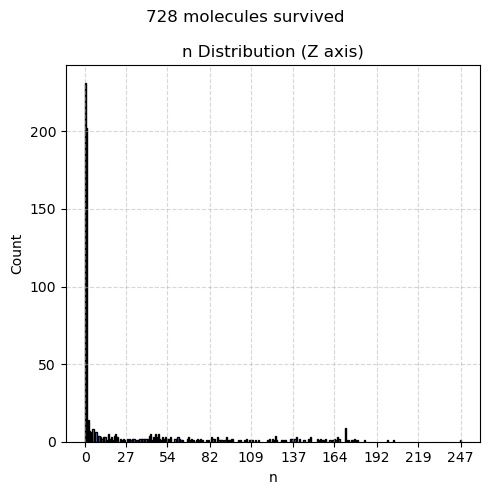

{'survival_rate_mean': array(0.728),
 'survival_rate_sem': array(0.00044273),
 'mot_mean': array([ 1.4010989 ,  2.57554945, 28.0521978 ]),
 'mot_sem': array([0.00590068, 0.0084315 , 0.05831912]),
 'ground_state_rate_mean': array(0.27197802),
 'ground_state_rate_sem': array(0.00053323),
 'N': array(1000, dtype=int32),
 'Ns_surv': array(728, dtype=int32),
 'B': array(1000, dtype=int32)}

In [15]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(1000, temp)
cr.raman_cool_with_pumping(mol_0, seq_cap, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
result

### Rebuild block

In [16]:
np.save("seq_cap_0406.npy", seq_cap)

In [ ]:
seq_list = np.unique(seq_cap, axis=0)
np.save("seq_list_0406.npy", seq_list)

In [22]:
seq_list

array([[ 0.00000000e+00, -3.00000000e+00,  1.84187616e+04,
         7.63928164e-05],
       [ 0.00000000e+00, -2.00000000e+00,  1.45368382e+04,
         9.39173207e-05],
       [ 0.00000000e+00, -1.00000000e+00,  7.84287242e+03,
         1.34476841e-04],
       [ 1.00000000e+00, -3.00000000e+00,  1.85722610e+04,
         7.00206985e-05],
       [ 1.00000000e+00, -2.00000000e+00,  1.18053453e+04,
         1.04600718e-04],
       [ 1.00000000e+00, -1.00000000e+00,  5.65819742e+03,
         1.58817067e-04],
       [ 2.00000000e+00, -1.00000000e+01,  1.00000000e+04,
         2.66231928e-05],
       [ 2.00000000e+00, -9.00000000e+00,  1.00000000e+04,
         4.27740350e-05],
       [ 2.00000000e+00, -8.00000000e+00,  1.00000000e+04,
         4.10213287e-05],
       [ 2.00000000e+00, -7.00000000e+00,  1.00000000e+04,
         2.18312536e-05],
       [ 2.00000000e+00, -6.00000000e+00,  1.00000000e+04,
         4.91887879e-05],
       [ 2.00000000e+00, -5.00000000e+00,  1.00000000e+04,
      

In [6]:
def get_sequence_block(indices, repeats, seq_list):
    block = seq_list[indices]
    return np.tile(block, (repeats, 1))
def build_sequence(block_specs, seq_list):
    blocks = [
        get_sequence_block(indices, repeats, seq_list)
        for indices, repeats in block_specs
    ]
    return np.vstack(blocks)

In [7]:
import numpy as np

def rows_to_indices(seq_cap, seq_list, atol=1e-12, rtol=1e-9):
    """
    Convert each row in seq_cap into the matching row index in seq_list.
    
    Returns
    -------
    indices : (len(seq_cap),) integer array
    """
    indices = []

    for row in seq_cap:
        matches = np.where(np.all(np.isclose(seq_list, row, atol=atol, rtol=rtol), axis=1))[0]

        if len(matches) == 0:
            raise ValueError(f"No match found in seq_list for row:\n{row}")
        if len(matches) > 1:
            raise ValueError(f"Ambiguous match for row:\n{row}\nMatches: {matches}")

        indices.append(matches[0])

    return np.array(indices, dtype=int)


def compress_indices_to_blocks(indices):
    """
    Compress an index sequence into block_specs = [(pattern, repeats), ...]
    
    Greedy strategy:
    - at each position, find the longest pattern that repeats contiguously
    - if nothing repeats, emit one item with repeat=1
    
    Example:
    [6,7,8,9, 6,7,8,9, 6,7,8,9] -> [(array([6,7,8,9]), 3)]
    """
    indices = np.asarray(indices, dtype=int)
    n = len(indices)
    block_specs = []
    i = 0

    while i < n:
        best_pattern = None
        best_repeats = 1
        best_score = 1

        max_pat_len = (n - i) // 2
        for pat_len in range(1, max_pat_len + 1):
            pattern = indices[i:i + pat_len]
            repeats = 1

            while i + (repeats + 1) * pat_len <= n:
                next_chunk = indices[i + repeats * pat_len : i + (repeats + 1) * pat_len]
                if np.array_equal(next_chunk, pattern):
                    repeats += 1
                else:
                    break

            score = pat_len * repeats
            if repeats > 1 and score > best_score:
                best_pattern = pattern
                best_repeats = repeats
                best_score = score

        if best_pattern is not None:
            block_specs.append((best_pattern.copy(), best_repeats))
            i += len(best_pattern) * best_repeats
        else:
            block_specs.append((np.array([indices[i]]), 1))
            i += 1

    return block_specs


def reverse_engineer_blocks(seq_cap, seq_list, atol=1e-12, rtol=1e-9):
    """
    Full pipeline:
    seq_cap -> index sequence -> block_specs
    """
    indices = rows_to_indices(seq_cap, seq_list, atol=atol, rtol=rtol)
    block_specs = compress_indices_to_blocks(indices)
    return indices, block_specs

In [33]:
indices, block_specs = reverse_engineer_blocks(seq_cap, seq_list)

print(indices)
for k, (pattern, repeats) in enumerate(block_specs, 1):
    print(f"block_{k} = get_sequence_block(np.array({pattern.tolist()}), {repeats}, seq_list)")

[ 6  7  8  9  6  7  8  9  6  7  8  9  6  7  8  9  6  7  8  9  6  7  8  9
  0  6  7  8  9  3  6  7  8  9  0  6  7  8  9  3  6  7  8  9  0  6  7  8
  9  3  6  7  8  9  0  6  7  8  9  3  6  7  8  9  0  6  7  8  9  3  6  7
  8  9  0  6  7  8  9  3  8  9 10 11  1  8  9 10 11  4  8  9 10 11  1  8
  9 10 11  4  8  9 10 11  1  8  9 10 11  4  8  9 10 11  1  8  9 10 11  4
  8  9 10 11  1  8  9 10 11  4  8  9 10 11  1  8  9 10 11  4 10 11 12 13
  2 10 11 12 13  5 10 11 12 13  2 10 11 12 13  5 10 11 12 13  2 10 11 12
 13  5 10 11 12 13  2 10 11 12 13  5 10 11 12 13  2 10 11 12 13  5 10 11
 12 13  2 10 11 12 13  5 12 13 14 15  2 14 15 12 13  5 12 13 14 15  2 14
 15 12 13  5 12 13 14 15  2 14 15 12 13  5 12 13 14 15  2 14 15 12 13  5
 12 13 14 15  2 14 15 12 13  5 12 13 14 15  2 14 15 12 13  5]
block_1 = get_sequence_block(np.array([6, 7, 8, 9]), 6, seq_list)
block_2 = get_sequence_block(np.array([0, 6, 7, 8, 9, 3, 6, 7, 8, 9]), 5, seq_list)
block_3 = get_sequence_block(np.array([0]), 1, seq_list)
b

In [34]:
block_1 = get_sequence_block(np.array([6, 7, 8, 9]), 6, seq_list)
block_2 = get_sequence_block(np.array([0, 6, 7, 8, 9, 3, 6, 7, 8, 9]), 5, seq_list)
block_3 = get_sequence_block(np.array([8, 9, 10, 11, 1, 8, 9, 10, 11, 4]), 6, seq_list)
block_4 = get_sequence_block(np.array([10, 11, 12, 13, 2, 10, 11, 12, 13, 5]), 6, seq_list)
block_5 = get_sequence_block(np.array([12, 13, 14, 15, 2, 14, 15, 12, 13, 5]), 6, seq_list)

In [36]:
rebuilt_seq = np.vstack([block_1, block_2, block_3, block_4, block_5])

In [37]:
rebuilt_seq

array([[ 2.00000000e+00, -1.00000000e+01,  1.00000000e+04,
         2.66231928e-05],
       [ 2.00000000e+00, -9.00000000e+00,  1.00000000e+04,
         4.27740350e-05],
       [ 2.00000000e+00, -8.00000000e+00,  1.00000000e+04,
         4.10213287e-05],
       ...,
       [ 2.00000000e+00, -4.00000000e+00,  5.03915688e+03,
         1.15801219e-04],
       [ 2.00000000e+00, -3.00000000e+00,  2.26278639e+03,
         1.86457720e-04],
       [ 1.00000000e+00, -1.00000000e+00,  5.65819742e+03,
         1.58817067e-04]], shape=(254, 4))

Raman pulses: 100%|██████████| 254/254 [00:15<00:00, 16.75it/s]


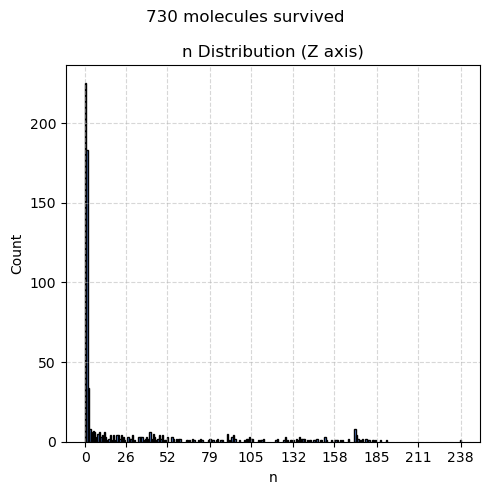

{'survival_rate_mean': array(0.73),
 'survival_rate_sem': array(0.00044838),
 'mot_mean': array([ 1.73287671,  2.81917808, 28.15753425]),
 'mot_sem': array([0.00660481, 0.00899112, 0.05806298]),
 'ground_state_rate_mean': array(0.25616438),
 'ground_state_rate_sem': array(0.00050877),
 'N': array(1000, dtype=int32),
 'Ns_surv': array(730, dtype=int32),
 'B': array(1000, dtype=int32)}

In [38]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(1000, temp)
cr.raman_cool_with_pumping(mol_0, rebuilt_seq, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
result

In [40]:
indices, block_specs = reverse_engineer_blocks(rebuilt_seq, seq_list)

print(indices)
for k, (pattern, repeats) in enumerate(block_specs, 1):
    print(f"block_{k} = get_sequence_block(np.array({pattern.tolist()}), {repeats}, seq_list)")

[ 6  7  8  9  6  7  8  9  6  7  8  9  6  7  8  9  6  7  8  9  6  7  8  9
  0  6  7  8  9  3  6  7  8  9  0  6  7  8  9  3  6  7  8  9  0  6  7  8
  9  3  6  7  8  9  0  6  7  8  9  3  6  7  8  9  0  6  7  8  9  3  6  7
  8  9  8  9 10 11  1  8  9 10 11  4  8  9 10 11  1  8  9 10 11  4  8  9
 10 11  1  8  9 10 11  4  8  9 10 11  1  8  9 10 11  4  8  9 10 11  1  8
  9 10 11  4  8  9 10 11  1  8  9 10 11  4 10 11 12 13  2 10 11 12 13  5
 10 11 12 13  2 10 11 12 13  5 10 11 12 13  2 10 11 12 13  5 10 11 12 13
  2 10 11 12 13  5 10 11 12 13  2 10 11 12 13  5 10 11 12 13  2 10 11 12
 13  5 12 13 14 15  2 14 15 12 13  5 12 13 14 15  2 14 15 12 13  5 12 13
 14 15  2 14 15 12 13  5 12 13 14 15  2 14 15 12 13  5 12 13 14 15  2 14
 15 12 13  5 12 13 14 15  2 14 15 12 13  5]
block_1 = get_sequence_block(np.array([6, 7, 8, 9]), 6, seq_list)
block_2 = get_sequence_block(np.array([0, 6, 7, 8, 9, 3, 6, 7, 8, 9]), 5, seq_list)
block_3 = get_sequence_block(np.array([8, 9, 10, 11, 1, 8, 9, 10, 11, 4]), 6

In [41]:
np.save("seq_rebuilt_0406.npy", rebuilt_seq)

### No cap

In [9]:
seq_op = np.load("../../new_sequence_optimization/op_amp_time/omega_time_ga_runs/OmegaTimeGA_20260210_141340/final_top5/top1_sequence.npy")
seq_list = np.unique(seq_op, axis=0)

block_1 = get_sequence_block(np.array([6, 7, 8, 9]), 6, seq_list)
block_2 = get_sequence_block(np.array([0, 6, 7, 8, 9, 3, 6, 7, 8, 9]), 5, seq_list)
block_3 = get_sequence_block(np.array([8, 9, 10, 11, 1, 8, 9, 10, 11, 4]), 6, seq_list)
block_4 = get_sequence_block(np.array([10, 11, 12, 13, 2, 10, 11, 12, 13, 5]), 6, seq_list)
block_5 = get_sequence_block(np.array([12, 13, 14, 15, 2, 14, 15, 12, 13, 5]), 6, seq_list)

rebuilt_seq_nocap = np.vstack([block_1, block_2, block_3, block_4, block_5])

Raman pulses: 100%|██████████| 254/254 [00:14<00:00, 17.18it/s]


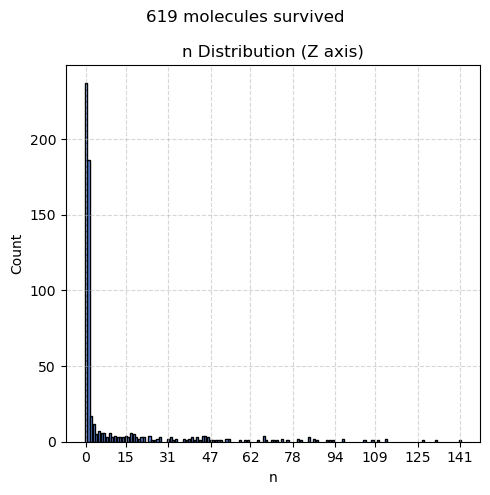

{'survival_rate_mean': array(0.619),
 'survival_rate_sem': array(0.00048445),
 'mot_mean': array([ 0.83521809,  1.36833603, 10.32148627]),
 'mot_sem': array([0.00367194, 0.00512387, 0.0289269 ]),
 'ground_state_rate_mean': array(0.32956381),
 'ground_state_rate_sem': array(0.00060086),
 'N': array(1000, dtype=int32),
 'Ns_surv': array(619, dtype=int32),
 'B': array(1000, dtype=int32)}

In [11]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(1000, temp)
cr.raman_cool_with_pumping(mol_0, rebuilt_seq_nocap, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
result

In [12]:
np.save("seq_rebuilt_nocap_0406.npy", rebuilt_seq_nocap)